# Data example

A walk-through of loading and inspecting a curve dataset from `inputs/`. Pick a `CURVE`, load its daily par-rate series, and look at coverage, summary statistics, and a few plots — the same data that feeds covariance estimation.

In [1]:
import sys
from pathlib import Path

# Make the project package importable regardless of where Jupyter was launched.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_rates
from src.tenor_graph import tenor_to_years

INPUTS = ROOT / "inputs"
print("available curves:", [p.name for p in sorted(INPUTS.iterdir()) if p.is_dir()])

available curves: ['CAD', 'TOY']


## 1. Load a curve

Each curve folder holds `curve_data.csv` (daily par rates in long form) and `tenor_structure.json`. Set `CURVE` to one of the names above. The CSV carries a few constant metadata columns alongside the `Date / Tenor / ParRate` series.

In [2]:
CURVE = "CAD"
base  = INPUTS / CURVE

raw = pd.read_csv(base / "curve_data.csv", parse_dates=["Date"])
print("raw shape:", raw.shape)
print(raw[["Currency", "DiscCurve", "ForecastCurve"]].iloc[0].to_string())
raw.head()

raw shape: (3930, 6)
Currency                  CAD
DiscCurve        CAD.CORRA.1B
ForecastCurve    CAD.CORRA.1B


,Date,Currency,DiscCurve,ForecastCurve,Tenor,ParRate
0,2024-01-01,CAD,CAD.CORRA.1B,CAD.CORRA.1B,3M,2.610564
1,2024-01-01,CAD,CAD.CORRA.1B,CAD.CORRA.1B,6M,2.673259
2,2024-01-01,CAD,CAD.CORRA.1B,CAD.CORRA.1B,9M,2.731680
3,2024-01-01,CAD,CAD.CORRA.1B,CAD.CORRA.1B,1Y,2.785844
4,2024-01-01,CAD,CAD.CORRA.1B,CAD.CORRA.1B,18M,2.881938


## 2. Pivot to a wide rate table

`load_rates` pivots the long CSV into a `Date x Tenor` table with tenors sorted by maturity — exactly the shape the estimators consume.

In [3]:
rates = load_rates(base / "curve_data.csv")
print(f"{rates.shape[0]} dates x {rates.shape[1]} tenors")
print("date range:", rates.index.min().date(), "->", rates.index.max().date())
print("tenors:", list(rates.columns))
rates.head()

262 dates x 15 tenors
date range: 2024-01-01 -> 2024-12-31
tenors: ['3M', '6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']


Tenor,3M,6M,9M,1Y,18M,2Y,3Y,4Y,5Y,7Y,10Y,15Y,20Y,25Y,30Y
Date,,,,,,,,,,,,,,,
2024-01-01,2.610564,2.673259,2.731680,2.785844,2.881938,2.963113,3.088556,3.177089,3.240419,3.321411,3.386032,3.437035,3.462568,3.477889,3.488102
2024-01-02,2.620484,2.687195,2.749191,2.805440,2.904155,2.986342,3.111077,3.201186,3.263616,3.343411,3.405379,3.455588,3.482646,3.496639,3.507337
2024-01-03,2.645510,2.714867,2.780020,2.836930,2.939592,3.023889,3.152421,3.245012,3.309598,3.390757,3.455985,3.505394,3.533679,3.547835,3.560543
2024-01-04,2.707441,2.774866,2.835516,2.892545,2.993708,3.076159,3.204932,3.296070,3.362800,3.445485,3.508845,3.558771,3.589043,3.603519,3.614276
2024-01-05,2.699187,2.767931,2.828853,2.887525,2.990976,3.075891,3.209007,3.303111,3.373040,3.455950,3.523391,3.573936,3.605083,3.620784,3.630171


## 3. Coverage & summary stats

Check for missing observations (gaps where a tenor wasn't quoted), then look at the per-tenor level distribution.

In [4]:
missing = rates.isna().sum()
print("missing values per tenor:")
print(missing[missing > 0].to_string() if missing.any() else "  none")

rates.describe().round(3).T

missing values per tenor:
  none


,count,mean,std,min,25%,50%,75%,max
Tenor,,,,,,,,
3M,262.0,2.304,0.172,1.890,2.168,2.326,2.447,2.707
6M,262.0,2.452,0.143,2.093,2.356,2.474,2.552,2.775
9M,262.0,2.582,0.128,2.277,2.498,2.577,2.675,2.929
1Y,262.0,2.691,0.127,2.412,2.606,2.680,2.785,3.056
18M,262.0,2.877,0.135,2.648,2.763,2.874,2.970,3.270
2Y,262.0,3.016,0.147,2.730,2.901,3.031,3.114,3.423
3Y,262.0,3.217,0.163,2.874,3.111,3.240,3.319,3.632
4Y,262.0,3.344,0.170,2.966,3.232,3.366,3.456,3.745
5Y,262.0,3.430,0.171,3.039,3.317,3.454,3.551,3.818


## 4. Par-rate history

Levels through time for every tenor — the whole term structure moving day to day.

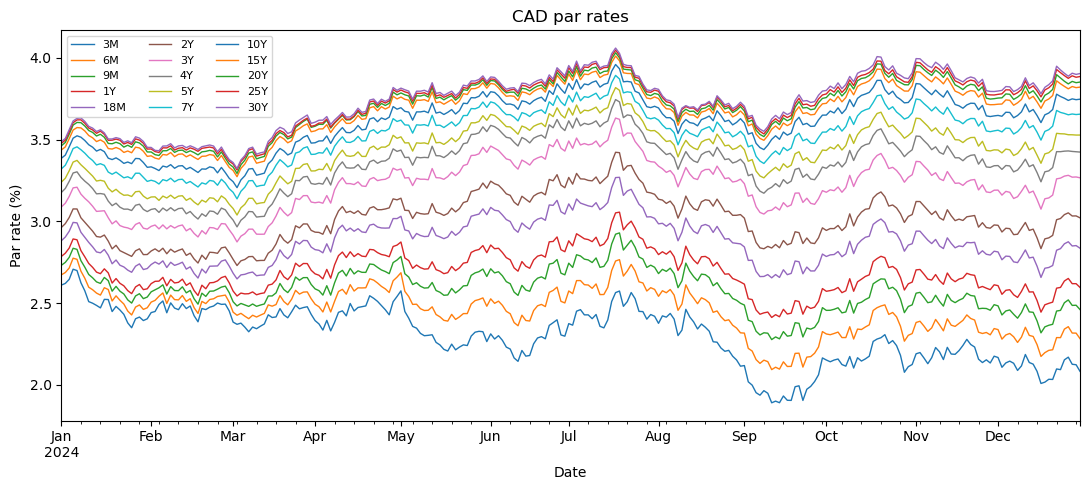

In [5]:
ax = rates.plot(figsize=(11, 5), lw=1)
ax.set(xlabel="Date", ylabel="Par rate (%)", title=f"{CURVE} par rates")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()

## 5. Snapshot yield curves

A handful of evenly spaced dates plotted against maturity show the curve shape (upward-sloping / inverted) on each day.

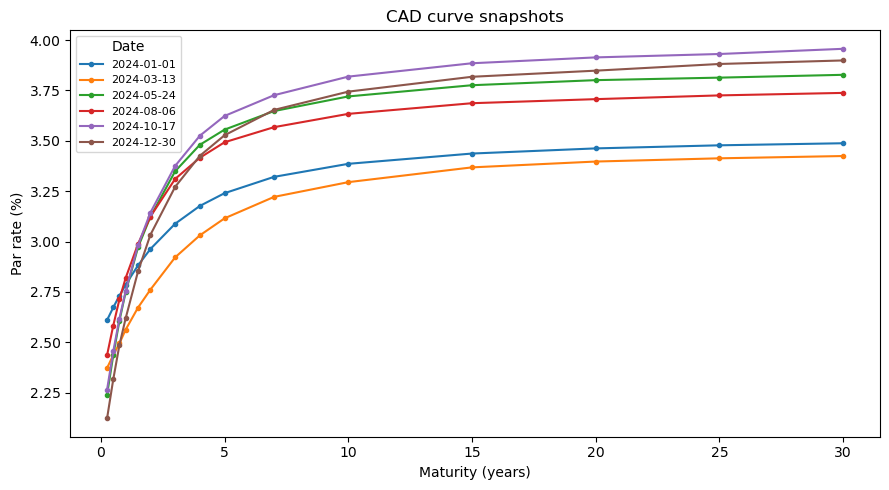

In [6]:
years  = [tenor_to_years(t) for t in rates.columns]
sample = rates.iloc[:: max(len(rates) // 5, 1)]   # ~5 evenly spaced dates

fig, ax = plt.subplots(figsize=(9, 5))
for date, row in sample.iterrows():
    ax.plot(years, row.values, marker="o", ms=3, label=date.date())
ax.set(xlabel="Maturity (years)", ylabel="Par rate (%)", title=f"{CURVE} curve snapshots")
ax.legend(title="Date", fontsize=8)
plt.tight_layout()

## 6. Daily changes

Covariance estimation runs on daily *changes*, not levels. Here are their scale per tenor and the pairwise correlation across the curve — neighbouring tenors move almost in lockstep, which is what dimension reduction exploits.

261 daily changes


Tenor,3M,6M,9M,1Y,18M,2Y,3Y,4Y,5Y,7Y,10Y,15Y,20Y,25Y,30Y
daily vol,0.0429,0.0403,0.0387,0.0378,0.0364,0.0356,0.0343,0.0333,0.0325,0.0317,0.0313,0.031,0.0311,0.031,0.0311


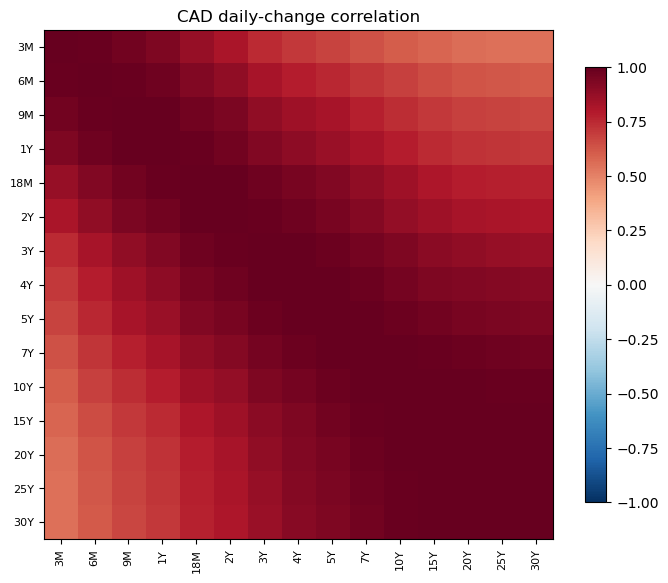

In [7]:
changes = rates.diff().dropna()
print(f"{changes.shape[0]} daily changes")
display(changes.std().round(4).rename("daily vol").to_frame().T)

corr = changes.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
ax.set_title(f"{CURVE} daily-change correlation")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()